In [ ]:
!pip install scikit-learn
!pip install python-dotenv

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import os
from google import genai
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
# Config
INPUT_FILE = "reddit_data_with_topics_min_10_no_auto_reduce_mpnet.csv"
THRESHOLD_PERCENT = 0.015 # Since each community has at least 600 posts, this means we will only keep topics that appear in at least 9+ posts
API_KEY = os.getenv("Gemma_API_KEY")

## Load the data into a pandas dataframe

In [11]:
df = pd.read_csv(INPUT_FILE)

# First we can remove -1 topics
df_clean = df[df['Topic'] != -1].copy()

Clean the topics to make them more human readable, I used the free gemma 3 27b it model for this

In [12]:
client = genai.Client(api_key=API_KEY)  
unique_topics = df_clean["Topic_Name"].unique()

prompt = (
    "Rename each topic to a short 4-word Category Label that is human readable. Be sure to include some identifier and not to be overly vague with topics. Do not include formatting in the output  Follow this format: Format: Original|Label\n"
    + "\n".join(unique_topics)
)
response = client.models.generate_content(model="gemma-3-27b-it", contents=prompt)

label_map = {
    line.split("|")[0].strip(): line.split("|")[1].strip()
    for line in response.text.split("\n")
    if "|" in line
}
df_clean["Label"] = df_clean["Topic_Name"].map(label_map).fillna(df_clean["Topic_Name"])

## 2.2 Now we can create the binary matrix by applying the threshold

In [13]:
counts = pd.crosstab(df_clean['subreddit'], df_clean['Label'])
subreddit_totals = counts.sum(axis=1)

binary_matrix = counts.copy()
for sub in counts.index:
    threshold = subreddit_totals[sub] * THRESHOLD_PERCENT
    binary_matrix.loc[sub] = (counts.loc[sub] >= threshold).astype(int)

binary_matrix

Label,AI Age Verification for Online Content,AI Artists on Spotify Platform,Ace Frehley & Homayoun Ershadi Deaths,Arc Raiders Game Discussion,Asylum Policy Overhaul Discussion,Bad Bunny Super Bowl Performance,Bitcoin Meme Daily Discussion,Bosnian War Tourism Controversy,COVID Relief Funding & Donations,COVID-19 Vaccine & Autism Concerns,...,Trump Approval Rating Polls,Trump China Trade Tariffs Debate,Trump Insider Trading Executive Order,Trump Pardons & Signature Verification,Venezuela Opposition & Capture Claims,Warner Bros Acquisition Bidding,Warren Buffett Berkshire Hathaway Meeting,Wealth Tax on Billionaires Debate,Women's Restroom Facility Details,YouTube TV Disney Blackout Dispute
subreddit,,,,,,,,,,,,,,,,,,,,,
AmIOverreacting,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bitcoin,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
ChatGPT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Music,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NoStupidQuestions,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
europe,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
gaming,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
investing,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
movies,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [14]:
binary_matrix.to_csv("binary_matrix.csv")

## 2.2.1 Now we can calculate cosine similarity

In [15]:
cosine_sim = cosine_similarity(binary_matrix)
cosine_df = pd.DataFrame(cosine_sim, index=binary_matrix.index, columns=binary_matrix.index)

In [16]:
cosine_df

subreddit,AmIOverreacting,Bitcoin,ChatGPT,Music,NoStupidQuestions,europe,gaming,investing,movies,nba,politics,programming,technology,wallstreetbets,worldnews
subreddit,,,,,,,,,,,,,,,
AmIOverreacting,1.000000,0.000000,0.301511,0.000000,0.408248,0.000000,0.316228,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Bitcoin,0.000000,1.000000,0.341882,0.000000,0.308607,0.000000,0.000000,0.285714,0.000000,0.000000,0.000000,0.218218,0.101015,0.125988,0.000000
ChatGPT,0.301511,0.341882,1.000000,0.123091,0.615457,0.095346,0.190693,0.227921,0.000000,0.301511,0.077850,0.522233,0.402911,0.100504,0.075378
Music,0.000000,0.000000,0.123091,1.000000,0.166667,0.129099,0.000000,0.000000,0.000000,0.000000,0.105409,0.000000,0.109109,0.000000,0.102062
NoStupidQuestions,0.408248,0.308607,0.615457,0.166667,1.000000,0.129099,0.258199,0.308607,0.000000,0.000000,0.105409,0.471405,0.327327,0.136083,0.102062
europe,0.000000,0.000000,0.095346,0.129099,0.129099,1.000000,0.000000,0.119523,0.000000,0.000000,0.163299,0.000000,0.338062,0.105409,0.474342
gaming,0.316228,0.000000,0.190693,0.000000,0.258199,0.000000,1.000000,0.119523,0.316228,0.000000,0.000000,0.182574,0.169031,0.000000,0.000000
investing,0.000000,0.285714,0.227921,0.000000,0.308607,0.119523,0.119523,1.000000,0.000000,0.000000,0.097590,0.436436,0.303046,0.503953,0.188982
movies,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.316228,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Let's visualize it as an sns heatmap

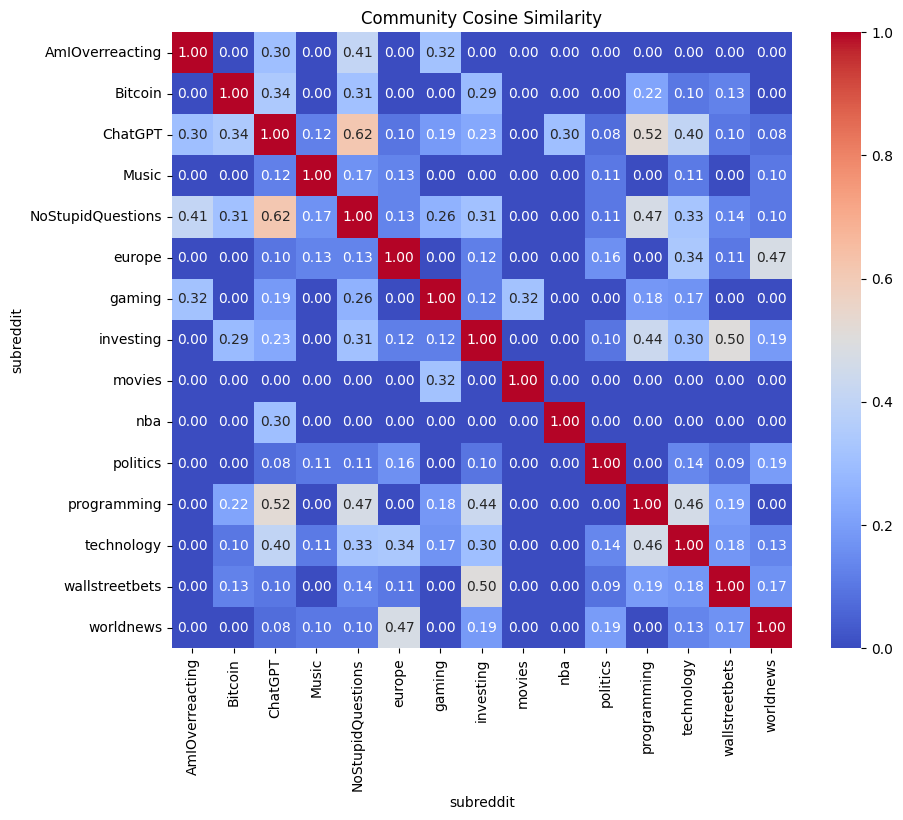

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_df, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Community Cosine Similarity")
plt.show()

## 2.2.2 K-Means Clustering

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(binary_matrix)

In [19]:
cluster_results = pd.DataFrame({'Subreddit': binary_matrix.index, 'Cluster': labels})
cluster_results = cluster_results.sort_values('Cluster')

In [20]:
cluster_results

,Subreddit,Cluster
10,politics,0
7,investing,1
13,wallstreetbets,1
5,europe,2
14,worldnews,2
0,AmIOverreacting,3
1,Bitcoin,3
2,ChatGPT,3
3,Music,3
4,NoStupidQuestions,3


To test multiple k values we can loop till n=15 since we chose 15 total subreddits

In [43]:
k_values = range(1, 16)
cluster_maps = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(binary_matrix)
    df_k = pd.DataFrame({'Subreddit': binary_matrix.index, 'Cluster': labels})
    for i in range(k):
        members = df_k[df_k['Cluster'] == i]['Subreddit'].tolist()
        print(f"Group {i}: {members}")

Group 0: ['AmIOverreacting', 'Bitcoin', 'ChatGPT', 'Music', 'NoStupidQuestions', 'europe', 'gaming', 'investing', 'movies', 'nba', 'politics', 'programming', 'technology', 'wallstreetbets', 'worldnews']
Group 0: ['europe', 'worldnews']
Group 1: ['AmIOverreacting', 'Bitcoin', 'ChatGPT', 'Music', 'NoStupidQuestions', 'gaming', 'investing', 'movies', 'nba', 'politics', 'programming', 'technology', 'wallstreetbets']
Group 0: ['europe', 'worldnews']
Group 1: ['AmIOverreacting', 'Bitcoin', 'Music', 'NoStupidQuestions', 'gaming', 'investing', 'movies', 'nba', 'politics', 'programming', 'wallstreetbets']
Group 2: ['ChatGPT', 'technology']
Group 0: ['AmIOverreacting', 'Bitcoin', 'ChatGPT', 'Music', 'NoStupidQuestions', 'gaming', 'investing', 'movies', 'nba', 'programming', 'wallstreetbets']
Group 1: ['europe', 'worldnews']
Group 2: ['technology']
Group 3: ['politics']
Group 0: ['politics']
Group 1: ['investing', 'wallstreetbets']
Group 2: ['europe', 'worldnews']
Group 3: ['AmIOverreacting', 'Bi

In [52]:
# Final K means with K=8
from sklearn.decomposition import PCA
k = 9
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(binary_matrix)

# We can reduce demisons to 2D for visualization
pca = PCA(n_components=2, random_state=42)
coordinates = pca.fit_transform(binary_matrix)

plot_df = pd.DataFrame({
    'Subreddit': binary_matrix.index,
    'Cluster': labels_final,
    'X': coordinates[:, 0],
    'Y': coordinates[:, 1]
})

In [53]:
# Now we can see the clusters
print(f"--- Cluster Members (K={k}) ---")
for i in range(k):
    members = plot_df[plot_df['Cluster'] == i]['Subreddit'].tolist()
    print(f"Cluster {i}: {members}")

--- Cluster Members (K=9) ---
Cluster 0: ['Bitcoin']
Cluster 1: ['AmIOverreacting', 'Music', 'movies', 'nba', 'programming']
Cluster 2: ['worldnews']
Cluster 3: ['europe']
Cluster 4: ['politics']
Cluster 5: ['technology']
Cluster 6: ['investing', 'wallstreetbets']
Cluster 7: ['ChatGPT', 'NoStupidQuestions']
Cluster 8: ['gaming']


## 2.2.3 Shared Topic Matrix

In [39]:
bin_copy = binary_matrix.copy()
shared_matrix = pd.DataFrame(0.0, index=binary_matrix.index, columns=binary_matrix.index)

# Now we iterate through each pair of subreddits and calculate the shared topic percentage
for sub in bin_copy.index:
    for sub2 in bin_copy.index:
        # we get the binary vectors for both subreddits
        v1 = bin_copy.loc[sub]
        v2 = bin_copy.loc[sub2]
        
        # Using formula given
        num_shared_topics = (v1 & v2).sum()
        total_distinct_topics = (v1 | v2).sum()
        # print(total_distinct_topics)
        
        if total_distinct_topics > 0:
            shared_matrix.loc[sub, sub2] = num_shared_topics / total_distinct_topics

Plotting the heatmap for same

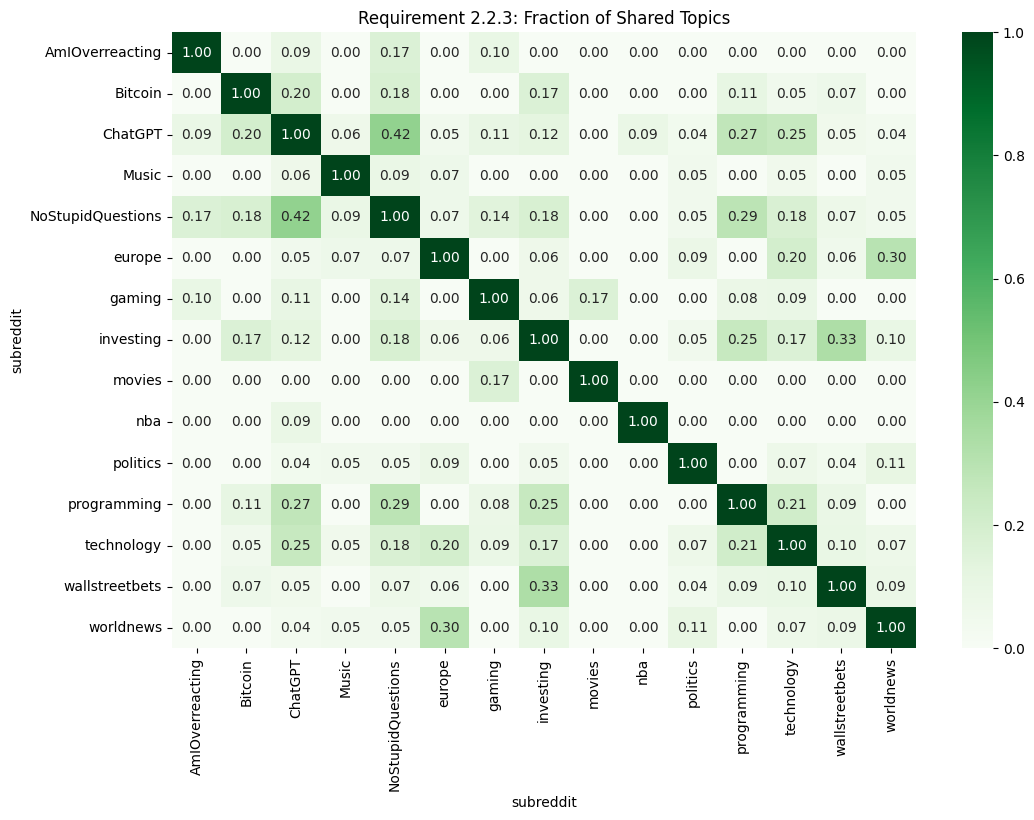

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(shared_matrix, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1)
plt.title("Requirement 2.2.3: Fraction of Shared Topics")
plt.show()

In [41]:
shared_matrix.to_csv("shared_topic_matrix.csv")

In [42]:
shared_matrix

subreddit,AmIOverreacting,Bitcoin,ChatGPT,Music,NoStupidQuestions,europe,gaming,investing,movies,nba,politics,programming,technology,wallstreetbets,worldnews
subreddit,,,,,,,,,,,,,,,
AmIOverreacting,1.000000,0.000000,0.090909,0.000000,0.166667,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Bitcoin,0.000000,1.000000,0.200000,0.000000,0.181818,0.000000,0.000000,0.166667,0.000000,0.000000,0.000000,0.111111,0.050000,0.066667,0.000000
ChatGPT,0.090909,0.200000,1.000000,0.062500,0.416667,0.050000,0.105263,0.125000,0.000000,0.090909,0.040000,0.272727,0.250000,0.052632,0.038462
Music,0.000000,0.000000,0.062500,1.000000,0.090909,0.066667,0.000000,0.000000,0.000000,0.000000,0.050000,0.000000,0.052632,0.000000,0.047619
NoStupidQuestions,0.166667,0.181818,0.416667,0.090909,1.000000,0.066667,0.142857,0.181818,0.000000,0.000000,0.050000,0.285714,0.176471,0.071429,0.047619
europe,0.000000,0.000000,0.050000,0.066667,0.066667,1.000000,0.000000,0.062500,0.000000,0.000000,0.086957,0.000000,0.200000,0.055556,0.300000
gaming,0.100000,0.000000,0.105263,0.000000,0.142857,0.000000,1.000000,0.062500,0.166667,0.000000,0.000000,0.083333,0.090909,0.000000,0.000000
investing,0.000000,0.166667,0.125000,0.000000,0.181818,0.062500,0.062500,1.000000,0.000000,0.000000,0.047619,0.250000,0.166667,0.333333,0.095238
movies,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [46]:
# Save final csv with clean names
df_clean.to_csv("reddit_data_with_topics_analyzed_clean_labels.csv", index=False)